In [108]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib as mpl
from matplotlib import font_manager
import math
import lightgbm as lgb
import numpy as np
import os
import json
import re

pd.set_option('display.max_columns', None)
# data_path = f'/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/{dataset}'
data_path = '/Users/yanjieni/Desktop/projects//脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)

# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

matplotlib 识别的字体名: Songti SC


In [109]:
# 提取当前数据集的数字
def extract_integers(s: str):
    """
    从字符串中提取所有整数，返回一个 int 列表
    """
    return list(map(int, re.findall(r"\d+", s)))



In [110]:
def label_encoding(filtered_df, data_path):
    columns_to_change1 = [item for item in filtered_df if item.endswith('_定性')]
    columns_to_change2 = [item for item in filtered_df if item.endswith('_描述性')]

    # 对每个object类型的列进行Label Encoding
    object_columns = columns_to_change1+columns_to_change2
    if 'filtered_patient1' in data_path or 'filtered_patient2' in data_path or 'filtered_patient5' in data_path:
        object_columns.remove('脑脊液_透明度_描述性')
        object_columns.remove('脑脊液_蛋白定性_定性')

    features_to_change = [ '血_抗双链DNA抗体_定性', '血_抗核抗体_定性', '血_抗胞浆型中性粒细胞抗体_定性', '血_抗核周型中性粒细胞抗体_定性', '血_梅毒非特异性抗体_定性', '血_梅毒螺旋体抗体_定性',
                        '血_人类免疫缺陷病毒抗体_定性', '血_不规则抗体_定性', '血_直接抗人球蛋白试验_定性', '血_结核感染T细胞检测_定性', '血_人类免疫缺陷病毒P24抗原_定性', '血_M蛋白_描述性']

    if 'filtered_patient2' in data_path or 'filtered_patient4' in data_path:
        for i in features_to_change:
            object_columns.remove(i)

    le_dict = {}
    for col in object_columns:
        le = LabelEncoder()
        # 处理空值：先用'unknown'填充，再进行编码
        filtered_df[col] = filtered_df[col].fillna('unknown')
        filtered_df[col] = le.fit_transform(filtered_df[col].astype(str))  # 确保没有NaN，否则会报错
        le_dict[col] = le  # 保存编码器，后续可能用于推理
    
    return filtered_df
    

In [111]:

# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '').replace('.', '').replace('(', '').replace(')', '').replace(':', '').replace(',', '').replace('"', '').replace('\\', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names


In [112]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

def bootstrap_auc_ci(y_true, y_score, B=1000, seed=2025, return_distribution=False):
    """
    Bootstrap percentile CI for ROC-AUC with stratified resampling on the test set.
    y_true: 1D array of {0,1}
    y_score: 1D array of predicted probabilities for class 1
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # 原始整套测试集点估计
    auc_point = roc_auc_score(y_true, y_score)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n_pos, n_neg = len(pos_idx), len(neg_idx)

    aucs = np.empty(B, dtype=float)
    for b in range(B):
        # 分层有放回采样，保持类样本量不变
        boot_pos = rng.choice(pos_idx, size=n_pos, replace=True)
        boot_neg = rng.choice(neg_idx, size=n_neg, replace=True)
        boot_idx = np.concatenate([boot_pos, boot_neg])

        # 计算本次 AUC
        aucs[b] = roc_auc_score(y_true[boot_idx], y_score[boot_idx])

    # 百分位 CI
    lower, median, upper = np.percentile(aucs, [2.5, 50.0, 97.5])
    if return_distribution:
        return {"point": auc_point, "median": median, "ci95": (lower, upper), "all": aucs}
    else:
        return {"point": auc_point, "median": median, "ci95": (lower, upper)}



In [113]:

def train(X_train, y_train, X_val, y_val):
    # 定义 Optuna 目标函数
    def objective(trial):
        # 建议超参数范围
        params = {
            'objective': 'binary',
            'metric': 'auc',
            'verbosity': -1,
            'boosting_type': 'gbdt',
            'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
            'num_leaves': trial.suggest_int('num_leaves', 20, 300, step=10),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'random_state': 42
        }
        
        # 添加类别权重处理不平衡数据（可选）
        if trial.suggest_categorical('use_scale_pos_weight', [True, False]):
            scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
            params['scale_pos_weight'] = scale_pos_weight
        
        # 训练模型
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],  # 早停防止过拟合
            # verbose=False
            # verbose = 1,
        )
        
        # 预测验证集概率
        y_val_pred_proba = model.predict_proba(X_val)[:, 1]
        
        # 计算 AUC
        auc_score = roc_auc_score(y_val, y_val_pred_proba)
        
        # 由于 Optuna 默认最小化目标函数，我们返回 1 - AUC 来最大化 AUC
        return 1.0 - auc_score

    # 创建 Optuna 研究
    study = optuna.create_study(
        direction='minimize',  # 最小化目标函数 (1 - AUC)
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # 10轮后开始剪枝
    )

    # 运行优化
    print("开始超参数优化...")
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    # 输出最佳结果
    print("\n优化完成!")
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
    print("  Best params: ")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    # 使用最佳参数重新训练最终模型
    print("\n使用最佳参数训练最终模型...")
    best_params = {k: v for k, v in best_trial.params.items() if k != 'use_scale_pos_weight'}
    best_params['random_state'] = 42
    best_params['objective'] = 'binary'
    best_params['verbose'] = 1

    # 如果使用了类别权重，添加回参数
    if 'use_scale_pos_weight' in best_trial.params and best_trial.params['use_scale_pos_weight']:
        best_params['scale_pos_weight'] = np.sum(y_train == 0) / np.sum(y_train == 1)

    final_model = lgb.LGBMClassifier(**best_params)
    final_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=20)],
        # verbose= 1
    )

    return [final_model,best_trial.params,best_params]

# 在各个数据集上评估最终模型
def evaluate_model(model, X, y, dataset_name, key):
    # y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]

    # 最佳阈值
    best_thresh, best_auc = 0.5, 0
    for thresh in np.arange(0.1, 0.65, 0.05):
        pred_val = (y_pred_proba > thresh).astype(int)
        f1 = roc_auc_score(y, pred_val)
        if f1 > best_auc:
            best_thresh, best_auc = thresh, f1

    print(f"最佳阈值: {best_thresh:.2f}，测试集最大auc: {best_auc:.4f}")

    y_pred = (y_pred_proba >= best_thresh).astype(int)
    
    # if dataset_name == '测试':
    #     predict = [[], []]
    #     y = list(y)
    #     for i in range(len(y)):
    #         if y[i] == 0:
    #             predict[0].append(y_pred_proba[i])
    #         if y[i] == 1:
    #             predict[1].append(y_pred_proba[i])
    #     group = key.split('vs')
    #     plt.boxplot(predict)
    #     plt.xticks([1, 2], [group[0], group[1]])
    #     plt.title(key)
    #     plt.ylabel("可能性")
    #     plt.show()

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred_proba)

    res_auc = bootstrap_auc_ci(y, y_pred_proba, B=1000, seed=2025)
    print(f"AUC = {res_auc['point']:.3f} "
        f"(95% CI {res_auc['ci95'][0]:.3f}–{res_auc['ci95'][1]:.3f})")

    # res_pr = bootstrap_prauc_ci(y_true_test, y_score_test, B=1000, seed=2025)
    # print(f"PR-AUC = {res_pr['point']:.3f} "
    #     f"(95% CI {res_pr['ci95'][0]:.3f}–{res_pr['ci95'][1]:.3f})")

    print(f"\n{dataset_name} 集评估结果:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'CI': (round(res_auc['ci95'][0],4),round(res_auc['ci95'][1],4))
    }

    # 评估训练集、验证集和测试集
    # train_auc, train_acc, train_f1 = evaluate_model(final_model, X_train, y_train, "训练")
    # val_auc, val_acc, val_f1 = evaluate_model(final_model, X_val, y_val, "验证")
    # test_auc, test_acc, test_f1 = evaluate_model(final_model, X_test, y_test, "测试")

    # 可选：保存最佳模型
    # import joblib
    # joblib.dump(final_model, 'best_lgb_model.pkl')
    # print("\n最佳模型已保存为 'best_lgb_model.pkl'")

    # 可选：绘制特征重要性
    # import matplotlib.pyplot as plt

    # plt.figure(figsize=(10, 8))
    # lgb.plot_importance(final_model, max_num_features=15)
    # plt.title('Feature Importance')
    # plt.tight_layout()
    # plt.show()

In [114]:
def draw_result(y_val, y_test, val_results, test_results, key, current_dataset):

    # 绘制ROC曲线
    plt.figure(figsize=(10, 8))

    # 计算各数据集的ROC曲线
    fpr_val, tpr_val, thresholds = roc_curve(y_val, val_results['y_pred_proba'])
    fpr_test, tpr_test, thresholds = roc_curve(y_test, test_results['y_pred_proba'])

    pd.DataFrame({
        "fpr": fpr_test,
        "tpr": tpr_test,
        "threshold": thresholds  
    }).to_csv(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/ROC/LightGBM/{key}/Dataset{current_dataset}_roc_curve.csv", index=False)


    # 绘制ROC曲线
    plt.plot(fpr_val, tpr_val, color='blue', lw=2, 
            label=f'验证集 AUC = {val_results["auc"]:.4f}')
    plt.plot(fpr_test, tpr_test, color='red', lw=2, 
            label=f'测试集 AUC = {test_results["auc"]:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{key} - LightGBM ROC曲线', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/LightGBM/ROC_AUC/Dataset{current_dataset}/{key}ROC-AUC.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    model = key
    data_to_append = {'val_accuracy':round(val_results['accuracy'],4),'val_precision':round(val_results['precision'],4),'val_recall':round(val_results['recall'],4),'val_f1':round(val_results['f1'],4),'roc_auc_val':round(val_results['auc'],4),'val_CI':val_results['CI'],
                    'test_accuracy':round(test_results['accuracy'],4),'test_precision':round(test_results['precision'],4),'test_recall':round(test_results['recall'],4),'test_f1':round(test_results['f1'],4),'roc_auc_test':round(test_results['auc'],4),'test_CI':test_results['CI']}
    # JSON 文件路径
    json_file = "/Users/yanjieni/Desktop/projects//脑脊液/naojiye/data/model_data4/LightGBM_data.json"

    # 如果文件存在，先读取已有数组，否则初始化为空列表
    if os.path.exists(json_file):
        with open(json_file, "r", encoding="utf-8") as f:
            try:
                existing_data = json.load(f)
                if f'LightGBM_Dataset{current_dataset}' not in existing_data:
                    existing_data[f'LightGBM_Dataset{current_dataset}'] = {}
            except json.JSONDecodeError:
                existing_data = {f'LightGBM_Dataset{current_dataset}':{}}
    else:
        existing_data = {f'LightGBM_Dataset{current_dataset}':{}}

    # 追加新的数据
    existing_data[f'LightGBM_Dataset{current_dataset}'][model] = data_to_append

    # 写回 JSON 文件
    with open(json_file, "w", encoding="utf-8") as f:
        json.dump(existing_data, f, ensure_ascii=False, indent=4)



In [115]:
def draw_shap(final_model, X_train, X_test, current_dataset, key):

    task_trans = {
        "阴性组vs其他": "NG vs Others",
        "感染性脑膜炎v非感染组": "Infectious Meningitis vs Non-Infectious ",
        "细菌性脑膜炎vs其他感染性脑膜炎": "ABM vs Other Infectious Meningitis",
        "病毒性脑膜炎vs其他感染性脑膜炎": "VM vs Other Infectious Meningitis",
        "结核性脑膜炎vs其他感染性脑膜炎": "TBM vs Other Infectious Meningitis",
        "真菌性脑膜炎vs其他感染性脑膜炎": "FM vs Other Infectious Meningitis",
        "肿瘤性脑膜炎vs其他": "LMD vs Others",
        "自身免疫性脑膜炎vs其他": "AE vs Others",
        "病毒性脑膜炎vs病毒性脑炎": "VM vs VE"
    }

    # ---------------- SHAP 分析 -----------------
    print(X_train.shape,X_test.shape)
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_test)
    shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values

    trans_df = pd.read_excel('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/ipynb/项目英文缩写与全称.xlsx')
    trans_dict = {}
    print(X_test.columns)
    for index, row in trans_df.iterrows():
        trans_dict[row['中文项目名称']] = row['英文缩写']
    # new_index = [x if x in ['age', 'gender'] else "_".join(x.split('_')[:-1]) for x in list(X_test.columns)]
    X_test = X_test.rename(columns={'血_葡萄糖空腹_定量': '血_葡萄糖[空腹]_定量'})
    X_test = X_test.rename(columns={'血_肌酸激酶.MB型质量法_定量': '血_肌酸激酶.MB型[质量法]_定量'})   
    X_test = X_test.rename(columns={'血_细胞CD3-CD19+百分比_定量': '血_细胞.CD3-CD19+百分比_定量'})   
    X_test = X_test.rename(columns={'血_13-β-D-葡聚糖_定量': '血_1,3-β-D-葡聚糖_定量'})   
    X_test = X_test.rename(columns={'血_细胞CD3+CD8+百分比_定量': '血_细胞.CD3+CD8+百分比_定量'})   
    X_test = X_test.rename(columns={'血_细胞CD3+CD4+百分比_定量': '血_细胞.CD3+CD4+百分比_定量'})   
    X_test = X_test.rename(columns={'血_细胞CD4+/CD8+_定量': '血_细胞.CD4+/CD8+_定量'}) 
    
    
    X_test.columns = [x if x in ['age', 'gender'] else "_".join(x.split('_')[:-1]) for i, x in enumerate(X_test.columns)]
     
    X_test_en = X_test.rename(columns=trans_dict)
    feature_names_en = list(X_test_en.columns)

    print(f"\n===== SHAP 特征重要性 (柱状图):  =====")
    plt.title(f"Features' Importance of {task_trans[key]} (Histogram)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    shap.summary_plot(shap_matrix, X_test, plot_type="bar", show=False, feature_names=feature_names_en)
    plt.gca().invert_xaxis()
    plt.savefig(f"/Users/yanjieni/Desktop/projects//脑脊液/naojiye/images/Dataset_v3/LightGBM/shap/Dataset{current_dataset}/{key}shap柱状图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    # print(f"/Users/yanjieni/Desktop/脑脊液/naojiye/images/XGBoost/shap/Dataset{current_dataset}/{key}shap柱状图.png")
    plt.show()

    # plt.title(f"{key}特征重要性(柱状图)", fontsize=16, fontweight='bold')
    plt.title(f"Features' Importance of {task_trans[key]} (Beeswarm Plot)", fontsize=16, fontweight='bold')
    plt.tight_layout()

    print(f"\n===== SHAP 特征分布 (蜂群图): =====")
    shap.summary_plot(shap_matrix, X_test, show=False, feature_names=feature_names_en)
    plt.savefig(f"/Users/yanjieni/Desktop/projects//脑脊液/naojiye/images/Dataset_v3/LightGBM/shap/Dataset{current_dataset}/{key}shap蜂群图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

[I 2025-10-29 10:01:43,765] A new study created in memory with name: no-name-e75a7be4-a7bd-4727-8ad8-19110757e7e3


开始超参数优化...


Best trial: 2. Best value: 0.135531:   9%|▉         | 9/100 [00:00<00:03, 27.14it/s]

[I 2025-10-29 10:01:43,824] Trial 0 finished with value: 0.1428571428571428 and parameters: {'n_estimators': 200, 'num_leaves': 290, 'max_depth': 10, 'learning_rate': 0.030405325392865647, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469887, 'min_child_samples': 62, 'use_scale_pos_weight': True}. Best is trial 0 with value: 0.1428571428571428.
[I 2025-10-29 10:01:43,860] Trial 1 finished with value: 0.184981684981685 and parameters: {'n_estimators': 500, 'num_leaves': 260, 'max_depth': 5, 'learning_rate': 0.002820996133514492, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.721696897183815, 'reg_alpha': 0.00052821153945323, 'reg_lambda': 7.71800699380605e-05, 'min_child_samples': 32, 'use_scale_pos_weight': True}. Best is trial 0 with value: 0.1428571428571428.
[I 2025-10-29 10:01:43,877] Trial 2 finished with value: 0.1355311355311355 and parameters: {'n_estimators': 150, 'num_leaves': 120

Best trial: 2. Best value: 0.135531:  11%|█         | 11/100 [00:00<00:01, 49.59it/s]

...

[I 2025-10-29 10:01:45,551] Trial 85 finished with value: 0.14743589743589736 and parameters: {'n_estimators': 200, 'num_leaves': 290, 'max_depth': 12, 'learning_rate': 0.08866507905881624, 'subsample': 0.9452417848401227, 'colsample_bytree': 0.7189069819074921, 'reg_alpha': 0.018169729562421934, 'reg_lambda': 4.176726078568919e-08, 'min_child_samples': 57, 'use_scale_pos_weight': True}. Best is trial 51 with value: 0.13278388278388276.
[I 2025-10-29 10:01:45,578] Trial 86 finished with value: 0.15842490842490842 and parameters: {'n_estimators': 250, 'num_leaves': 270, 'max_depth': 11, 'learning_rate': 0.04018140169191382, 'subsample': 0.6577227511661342, 'colsample_bytree': 0.7476637729373244, 'reg_alpha': 0.1638029593863542, 'reg_lambda': 6.874405554564072e-08, 'min_child_samples': 65, 'use_scale_pos_weight': True}. Best is trial 51 with value: 0.13278388278388276.
[I 2025-10-29 10:01:45,596] Trial 87 finished with value: 0.14560439560439564 and parameters: {'n_estimators': 150, 'num

Best trial: 51. Best value: 0.132784:  95%|█████████▌| 95/100 [00:01<00:00, 49.94it/s]

[I 2025-10-29 10:01:45,729] Trial 94 finished with value: 0.13461538461538458 and parameters: {'n_estimators': 300, 'num_leaves': 150, 'max_depth': 8, 'learning_rate': 0.16350283561617543, 'subsample': 0.6213259441745838, 'colsample_bytree': 0.7514213578042725, 'reg_alpha': 0.0003178795970465419, 'reg_lambda': 0.00014296746218329175, 'min_child_samples': 61, 'use_scale_pos_weight': True}. Best is trial 51 with value: 0.13278388278388276.
[I 2025-10-29 10:01:45,749] Trial 95 finished with value: 0.14560439560439564 and parameters: {'n_estimators': 300, 'num_leaves': 140, 'max_depth': 8, 'learning_rate': 0.17008529314104154, 'subsample': 0.6195196082463105, 'colsample_bytree': 0.7228182610123426, 'reg_alpha': 5.5779539509807694e-05, 'reg_lambda': 2.6768602736902183e-05, 'min_child_samples': 53, 'use_scale_pos_weight': True}. Best is trial 51 with value: 0.13278388278388276.


Best trial: 51. Best value: 0.132784: 100%|██████████| 100/100 [00:02<00:00, 48.36it/s]


[I 2025-10-29 10:01:45,767] Trial 96 finished with value: 0.15201465201465203 and parameters: {'n_estimators': 300, 'num_leaves': 150, 'max_depth': 8, 'learning_rate': 0.09966404495463974, 'subsample': 0.6284340976240138, 'colsample_bytree': 0.6564804382364795, 'reg_alpha': 0.00042706889899659685, 'reg_lambda': 0.00012047536328540525, 'min_child_samples': 69, 'use_scale_pos_weight': True}. Best is trial 51 with value: 0.13278388278388276.
[I 2025-10-29 10:01:45,786] Trial 97 finished with value: 0.15842490842490842 and parameters: {'n_estimators': 350, 'num_leaves': 170, 'max_depth': 7, 'learning_rate': 0.17591363501792961, 'subsample': 0.8039186872721128, 'colsample_bytree': 0.8220547919585728, 'reg_alpha': 0.7897582630342853, 'reg_lambda': 0.0001984720868186607, 'min_child_samples': 65, 'use_scale_pos_weight': False}. Best is trial 51 with value: 0.13278388278388276.
[I 2025-10-29 10:01:45,807] Trial 98 finished with value: 0.14560439560439564 and parameters: {'n_estimators': 400, 'n

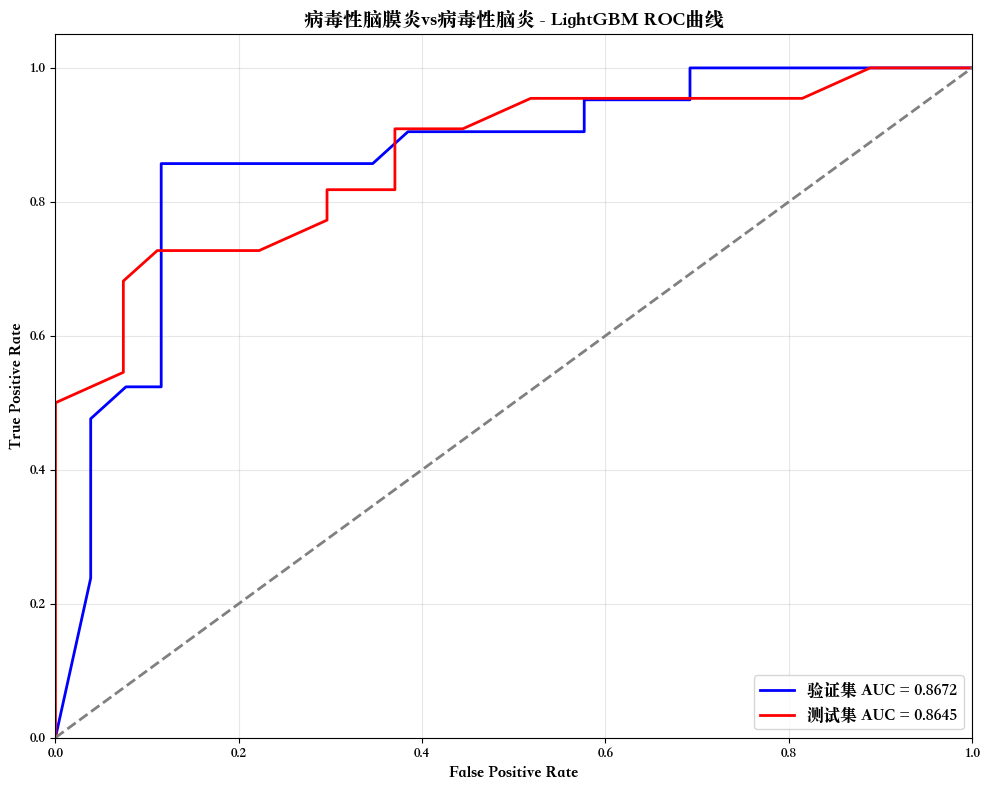

(142, 8) (49, 8)
Index(['脑脊液_有核细胞计数_定量', '血_降钙素原_定量', '血_同型半胱氨酸_定量', '血_细胞CD3+CD4+百分比_定量',
       '血_血小板分布宽度_定量', '血_细胞CD3+CD8+百分比_定量', '血_前白蛋白_定量', '血_铁蛋白_定量'],
      dtype='object')

===== SHAP 特征重要性 (柱状图):  =====


/opt/anaconda3/envs/naojiye/lib/python3.10/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


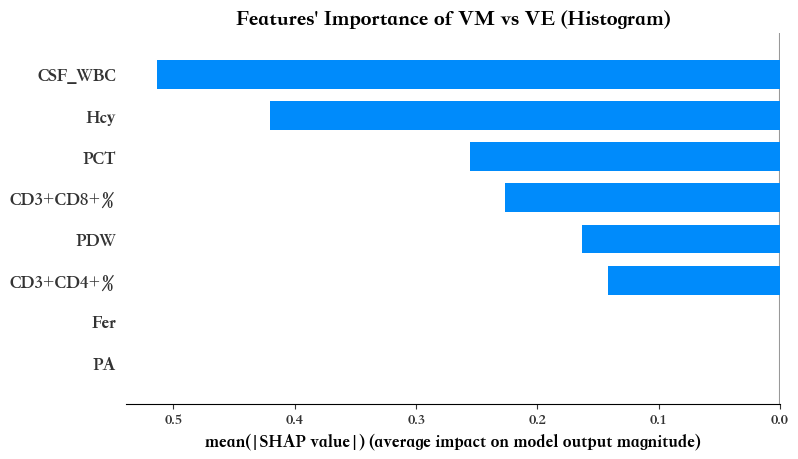


===== SHAP 特征分布 (蜂群图): =====


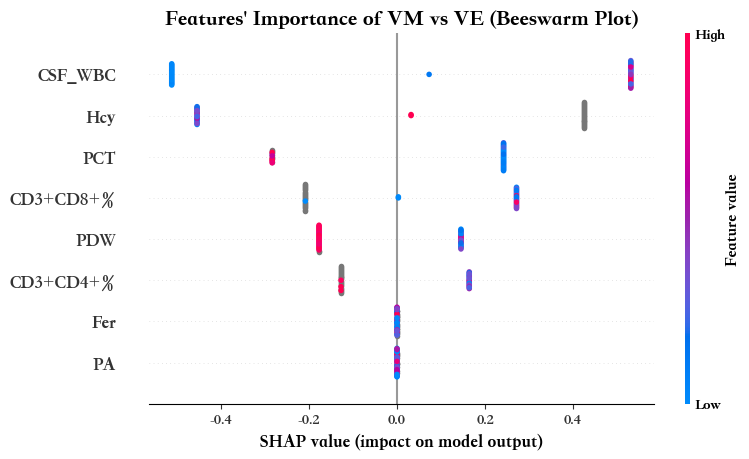

In [116]:

filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

screen_data = {
    # '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    # '感染性脑膜炎v非感染组': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    # '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    # '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    # '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    # '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    # '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    # '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }
data_shape = {}

def delete_same_col(df):
    same_cols = df.nunique() == 1
    d = dict(same_cols)
    none_feature = []
    for keys, items in d.items():
        if items == True:
            none_feature.append(keys)
    return df.drop(none_feature, axis=1)

def run_model(key, item, selected_df, current_dataset, data_shape):
    # 筛选需要的组别
    selected_df = selected_df[selected_df['分组'].isin(item[0])]

    # 删除数值一样的列  
    selected_df = delete_same_col(selected_df)

    # 选择特征 将数据正例和反例平均分配
    filter_1 = selected_df[selected_df["分组"].isin(item[1])]
    filter_2 = selected_df[selected_df["分组"].isin(item[2])]

    X_1 = filter_1[list(filter_1.columns)[:-2]]
    X_2 = filter_2[list(filter_2.columns)[:-2]]
    
    # 标签（分组，1 类与其他类）
    y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
    y_2 = (filter_2['分组'].isin(item[1])).astype(int) 

    # if current_dataset != 9:
    #     X = pd.concat([X_1,X_2])
    #     y = pd.concat([y_1,y_2])

    #     data_shape[key] = {'正例': y.sum(), '反例': (len(y) - y.sum())}

    # 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
    X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
    X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

    X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
    X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)


    # 将正例与反例拼接
    X_train = pd.concat([X_train_1,X_train_2])
    y_train = pd.concat([y_train_1,y_train_2])

    X_val = pd.concat([X_val_1,X_val_2])
    y_val = pd.concat([y_val_1,y_val_2])

    X_test = pd.concat([X_test_1,X_test_2])
    y_test = pd.concat([y_test_1,y_test_2])


    # if current_dataset != 9:
    #     # print("12312312312")
    #     data_shape[key] ={'训练集': {'正例': y_train.sum(), '反例': (len(y_train) - y_train.sum())}}
    #     data_shape[key]['验证集'] ={'正例': y_val.sum(), '反例': (len(y_val) - y_val.sum())}
    #     data_shape[key]['测试集'] ={'正例': y_test.sum(), '反例': (len(y_test) - y_test.sum())}
    # print(data_shape)
    
    # 创建 LightGBM 数据集（可以提高训练效率）
    train_data = lgb.Dataset(X_train, label=y_train)
    valid_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    # print(X_train.shape,X_test.shape)
    # 得到最优模型
    result = train(X_train, y_train, X_val, y_val)
    final_model = result[0]

    # 评估验证集和测试集
    val_results = evaluate_model(final_model, X_val, y_val, "验证", key)
    test_results = evaluate_model(final_model, X_test, y_test, "测试", key)    
    
    # 绘制ROC——AUC图 并存储数据
    draw_result(y_val, y_test, val_results, test_results, key, current_dataset)

    # 绘制shap图
    draw_shap(final_model, X_train, X_test, current_dataset, key)
    return result[2]

filtered_df1 = filtered_df.copy()

if extract_integers(data_path)[-1] == 2:
    # print(list(filtered_df1.columns))
    selected_features = {
        # '阴性组vs其他': filtered_df[['脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量','血_嗜酸性粒细胞百分比_定量','血_葡萄糖空腹_定量','血_结核感染T细胞检测_定性','血_乙型肝炎病毒核心抗体IgM_定量', '分组', '组名']],
        # '感染性脑膜炎v非感染组': filtered_df[['脑脊液_单个核细胞百分比_定量','脑脊液_葡萄糖_定量', '脑脊液_激活淋巴细胞_定量','脑脊液_多个核细胞百分比_定量', '分组', '组名']],
        # '细菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞CD3+CD8+百分比_定量','分组', '组名']],
        # '病毒性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_葡萄糖_定量','脑脊液_中性粒细胞百分比_定量','血_肌酸激酶_定量', '血_肾小球滤过率_定量', '血_免疫球蛋白E_定量','血_细胞CD3-CD16+CD56+百分比_定量','脑脊液_多个核细胞百分比_定量','脑脊液_蛋白定量_定量','分组', '组名']],
        # '结核性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_结核感染T细胞检测_定性','脑脊液_氯_定量','血_结核感染T细胞测试管_定量','脑脊液_葡萄糖_定量','血_淋巴细胞计数_定量','血_血小板分布宽度_定量', '血_铁蛋白_定量', '血_游离T4_定量', '分组', '组名']],
        # '真菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_细胞CD3-CD19+百分比_定量','血_不规则抗体_定性','血_梅毒非特异性抗体_定性', '脑脊液_有核细胞计数_定量', '分组', '组名']],
        # '肿瘤性脑膜炎vs其他': filtered_df[['脑脊液_蛋白定量_定量', '脑脊液_葡萄糖_定量', '脑脊液_多个核细胞百分比_定量', '脑脊液_淋巴细胞百分比_定量', 'age','分组', '组名']],
        # '自身免疫性脑膜炎vs其他': filtered_df[['血_丙型肝炎病毒抗体_定量','脑脊液_葡萄糖_定量','血_结核感染T细胞测试管_定量','血_铁蛋白_定量','脑脊液_蛋白定量_定量','血_D-二聚体_定量','血_乙型肝炎病毒核心抗体IgM_定量','age','分组', '组名']],
        '病毒性脑膜炎vs病毒性脑炎': filtered_df[['脑脊液_有核细胞计数_定量','血_降钙素原_定量','血_同型半胱氨酸_定量','血_细胞CD3+CD4+百分比_定量','血_血小板分布宽度_定量', '血_细胞CD3+CD8+百分比_定量', '血_前白蛋白_定量', '血_铁蛋白_定量', '分组', '组名']]
    }

current_dataset = extract_integers(data_path)[-1]
finish = 0
for key, item in screen_data.items():
    # 训练模型 - 数据集1-8
    
    # filtered_df2 = filtered_df.copy()
    # result_para = run_model(key, item, filtered_df2, current_dataset, data_shape)

     # 训练模型 - 精选特征数据集
    if current_dataset == 2:
        run_model(key, item, selected_features[key], 9, data_shape)

        



In [87]:
'''
# filtered_df = label_encoding(filtered_df, data_path)
# # 对 DataFrame 的列名进行清洗
# filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# # 数据预处理：将 'gender' 列转换为数值型
# filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

screen_data = {
    # '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    # '感染性脑膜炎v非感染组': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    # '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    # '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    '结核性脑膜炎vs其/他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    # '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    # '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    # '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    # '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

item = []
for key, item1 in screen_data.items():
    item = item1
print(item)
selected_df = filtered_df[filtered_df['分组'].isin(item[0])]

# 选择特征 将数据正例和反例平均分配
filter_1 = selected_df[selected_df["分组"].isin(item[1])]
filter_2 = selected_df[selected_df["分组"].isin(item[2])]

X_1 = filter_1[list(filter_1.columns)[2:-2]]
X_2 = filter_2[list(filter_2.columns)[2:-2]]
# print(X_1.columns)
# 标签（分组，1 类与其他类）
y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
y_2 = (filter_2['分组'].isin(item[1])).astype(int) 


# 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

# 将正例与反例拼接
X_train = pd.concat([X_train_1,X_train_2])
y_train = pd.concat([y_train_1,y_train_2])

X_val = pd.concat([X_val_1,X_val_2])
y_val = pd.concat([y_val_1,y_val_2])

X_test = pd.concat([X_test_1,X_test_2])
y_test = pd.concat([y_test_1,y_test_2])


'''

'\n# filtered_df = label_encoding(filtered_df, data_path)\n# # 对 DataFrame 的列名进行清洗\n# filtered_df.columns = clean_feature_names_simple(filtered_df.columns)\n\n# # 数据预处理：将 \'gender\' 列转换为数值型\n# filtered_df[\'gender\'] = filtered_df[\'gender\'].map({\'女\': 0, \'男\': 1})\n\nscreen_data = {\n    # \'阴性组vs其他\':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],\n    # \'感染性脑膜炎v非感染组\': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],\n    # \'细菌性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [1],  [2,3,4]],\n    # \'病毒性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [2], [1,3,4]],\n    \'结核性脑膜炎vs其/他感染性脑膜炎\': [[1,2,3,4], [3], [1,2,4]],\n    # \'真菌性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [4], [1,2,3]],\n    # \'肿瘤性脑膜炎vs其他\': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],\n    # \'自身免疫性脑膜炎vs其他\': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],\n    # \'病毒性脑膜炎vs病毒性脑炎\': [[2,8], [2], [8]]\n    }\n\nitem = []\nfor key, item1 in screen_data.items():\n    item = item1\nprint(item)\nselected_df = filtered_df[filtered_df[\'分组\'].isin(item[0])]\n\n# 选择特征 将数据正例和反例平均分配\nfilter_1 = selected_df[s

In [ ]:

'''

# params = {
#     'n_estimators': 1000,
#     'max_depth': 10,
#     'learning_rate': 0.0010217263561859077,
#     'subsample': 0.765745015802337,
#     'colsample_bytree': 0.7206332428817546,
#     'reg_alpha': 7.571565639799907e-07,
#     'reg_lambda':  0.007669065286362127,
#     'min_child_weight': 1,
#     'gamma': 0.028423560884985488,
#     'random_state': 42,
#     'use_label_encoder': False,
#     'eval_metric': 'logloss'   # 指定损失函数
# }
# result_para['n_estimators'] = 500
# result_para['random_state'] = 42
# result_para['use_label_encoder'] = False
# result_para['eval_metric'] = 'logloss'
# params = {
#     'n_estimators': 500,
#     'max_depth': 3,
#     'learning_rate': 0.014423244028784152,
#     'subsample': 0.9003002169351246,
#     'colsample_bytree': 0.8158764226043772,
#     'reg_alpha': 0.043594962064358575,
#     'reg_lambda':  0.4046273356274994,
#     'min_child_weight': 2,
#     'gamma': 0.24895493093075793,
#     'random_state': 42,
#     'use_label_encoder': False,
#     'eval_metric': 'logloss'   # 指定损失函数
# }


model = lgb.LGBMClassifier(**result_para)
# evals_result = {}
# 训练模型
model.fit(X_train, y_train,eval_set=[(X_train, y_train), (X_val, y_val)],  # 加入验证集
    eval_metric="logloss",
    # eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],
    # verbose=False,
    # evals_result=evals_result
)
evals_result = model.evals_result_

train_logloss = evals_result['training']['binary_logloss']
val_logloss = evals_result['valid_1']['binary_logloss']

test_results = evaluate_model(model, X_test, y_test, "测试", "阴性组")    
# print(test_results['auc'])
# 绘制曲线
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_logloss) + 1), train_logloss, label='Train Logloss')
plt.plot(range(1, len(val_logloss) + 1), val_logloss, label='Validation Logloss')
plt.xlabel('轮数')
plt.ylabel('损失')
plt.title(f'{list(screen_data.keys())[0]}损失曲线（拟合情况）')
plt.legend()
plt.show()

'''

In [ ]:
'''

with pd.ExcelWriter("/Users/yanjieni/Desktop/脑脊液/naojiye/正反例.xlsx", engine="openpyxl") as writer:
    for key, item in data_shape.items():
        ds = pd.DataFrame.from_dict(item)
        print(ds)
        
        sheet_name = f"{key}模型结果"  
        ds.to_excel(writer, sheet_name=sheet_name, index=True)

        # print(f"已保存到 {output_file} 的 sheet: {sheet_name}")
# records = []
# for dataset_name, comparisons in ds.items():
#             for comparison_name, metrics in comparisons.items():
#                 row = {"正反例": comparison_name, "任务组": metrics}
#                 row.update(metrics)
#                 records.append(row)
# records

'''

In [ ]:
'''

import pandas as pd
folder = "/Users/yanjieni/Desktop/脑脊液/naojiye/data/model_data"
all_files = []
for root, dirs, files in os.walk(folder):
    for file in files:
        all_files.append(os.path.join(root, file))

# 数据输出
output_file = "/Users/yanjieni/Desktop/脑脊液/naojiye/正反例.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    for file in all_files:
        data = pd.read_json(file)
        records = []

        for dataset_name, comparisons in data.items():
            for comparison_name, metrics in comparisons.items():
                row = {"数据集": dataset_name, "任务组": comparison_name}
                row.update(metrics)
                records.append(row)

        df = pd.DataFrame(records)

        df.sort_values(['数据集'])
        comparison_order = [
            "阴性组vs其他",
            "感染性脑膜炎v非感染组",
            "细菌性脑膜炎vs其他感染性脑膜炎",
            "病毒性脑膜炎vs其他感染性脑膜炎",
            "结核性脑膜炎vs其他感染性脑膜炎",
            "真菌性脑膜炎vs其他感染性脑膜炎",
            "肿瘤性脑膜炎vs其他",
            "自身免疫性脑膜炎vs其他",
            "病毒性脑膜炎vs病毒性脑炎"
        ]

        df["任务组"] = pd.Categorical(df["任务组"], categories=comparison_order, ordered=True)

        df = df.sort_values(by=["数据集", "任务组"]).reset_index(drop=True)
        
        sheet = ((file.split("/")[-1]).split(".")[0]).split("_")[0]
        sheet_name = f"{sheet}模型结果"  
        df.to_excel(writer, sheet_name=sheet_name, index=False)

        print(f"已保存到 {output_file} 的 sheet: {sheet_name}")
        
'''